# Scalable Quantum Error Correction
## Automated Pipelines with Stim and PyMatching

### 1. Motivation and Objectives
While manual circuit construction is essential for understanding QEC fundamentals, real-world research requires scalable and optimized workflows. This project transitions from "first-principles" implementation to using industry-standard tools for high-performance simulation and decoding.

**The focus of this study is:**
* **Scalable Generation:** Leveraging `stim.Circuit.generated` for standardized code construction.
* **Modern Decoding:** Implementing **Minimum-Weight Perfect Matching (MWPM)** via the `PyMatching` library.
* **Detector Error Models (DEM):** Analyzing how syndrome data is transformed into a graph structure for the decoder.
* **Threshold Estimation:** Identifying the physical error rate crossover point using larger code distances (up to $d=11$).

### 2. High-Level Circuit Construction
In this pipeline, I use Stim's built-in circuit generators. Unlike manual construction, these circuits come pre-annotated with `DETECTOR` and `OBSERVABLE_INCLUDE` instructions. These annotations are crucial because they define how measurement outcomes are correlated to specific error events, allowing the decoder to build an internal representation of the "decoding graph."

In [1]:
import stim
import numpy as np
import pymatching
import pandas as pd
import matplotlib.pyplot as plt

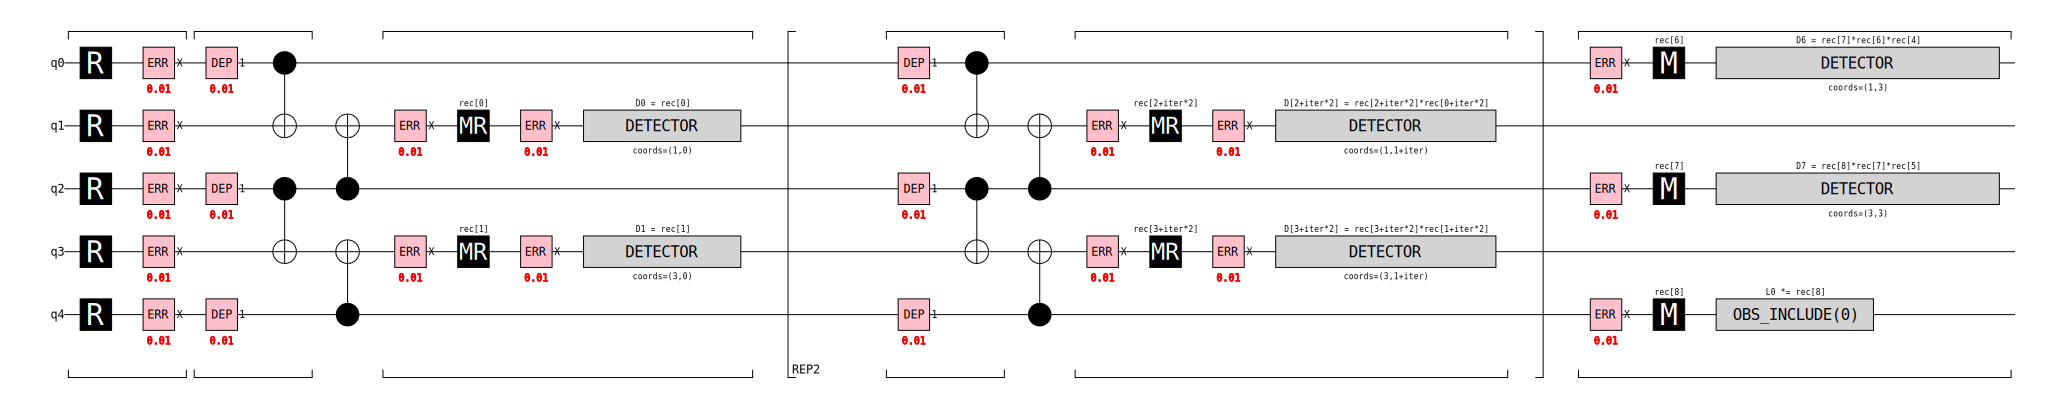

In [2]:
def generate_repetition_code_with_detectors(distance: int, rounds: int, noise_level: float) -> stim.Circuit:
    """
    Generates a repetition code circuit with standardized noise and detector annotations.
    """
    return stim.Circuit.generated(
        "repetition_code:memory",
        distance=distance,
        rounds=rounds,
        before_round_data_depolarization=noise_level,
        before_measure_flip_probability=noise_level,
        after_reset_flip_probability=noise_level
    )

# Visualizing a sample circuit to see DETECTOR annotations
sample_circuit = generate_repetition_code_with_detectors(distance=3, rounds=3, noise_level=0.01)
sample_circuit.diagram('timeline-svg')

### 3. Minimum-Weight Perfect Matching (MWPM)
Decoding is the process of identifying the most likely errors given a set of syndrome (detector) outcomes. I utilize `PyMatching`, which implements the MWPM algorithm. 

**The pipeline consists of:**
1. **Compiling the Detector Error Model (DEM):** Extracting the error probabilities and graph topology from the circuit.
2. **Sampling Detectors:** Simulating the circuit to get "detection events" (where parity changes).
3. **Graph Matching:** Finding the most probable chain of errors that explains the observed detectors.

In [3]:
def run_decoder_experiment(distance: int, rounds: int, noise_level: float, n_samples: int) -> float:
    circuit = generate_repetition_code_with_detectors(distance, rounds, noise_level)

    # 1. Compile the detector sampler
    sampler = circuit.compile_detector_sampler()
    # Separate observables (actual logical flips) from detectors (syndromes)
    detectors, actual_observables = sampler.sample(n_samples, separate_observables=True)

    # 2. Get the Detector Error Model and initialize the Matcher
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)

    # 3. Batch decoding for high performance
    predicted_observables = matcher.decode_batch(detectors)

    # 4. Calculate logical error rate
    num_errors = np.sum(np.any(predicted_observables != actual_observables, axis=1))
    return num_errors / n_samples

### 4. Performance Scaling and Threshold Analysis
By sweeping through noise levels and code distances, we can visualize the performance gains. For a repetition code, the logical error rate should decrease exponentially as the distance $d$ increases, provided the physical noise is below the threshold.

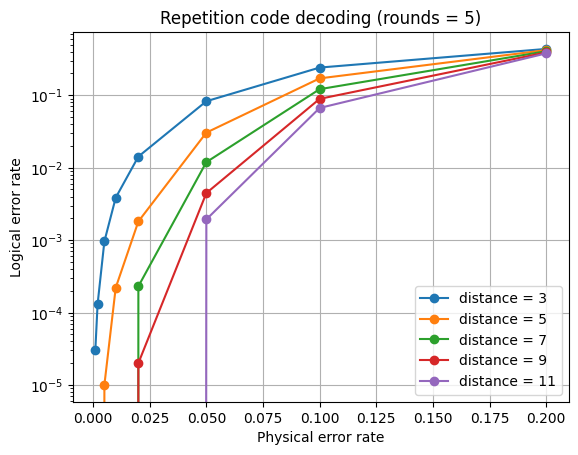

In [4]:
def collect_decoder_statistics(
    distances,
    rounds_list,
    noise_levels,
    n_samples
) -> pd.DataFrame:
    """
    Run decoder experiments for all combinations of distances, rounds, and noise levels.
    Collect results in a pandas DataFrame.
    """
    results = []

    for d in distances:
        for r in rounds_list:
            for p in noise_levels:
                ler = run_decoder_experiment(
                    distance=d,
                    rounds=r,
                    noise_level=p,
                    n_samples=n_samples
                )

                results.append({
                    "distance": d,
                    "rounds": r,
                    "noise_level": p,
                    "logical_error_rate": ler,
                })

    return pd.DataFrame(results)

def plot_logical_error_rate(df: pd.DataFrame, rounds: int):
    """
    Plot logical error rate as a function of noise level for different code distances.

    - df: DataFrame containing 'distance', 'rounds', 'noise_level', 'logical_error_rate'
    - rounds: the number of measurement rounds to filter by
    """
    plt.figure()

    for d in sorted(df["distance"].unique()):
        subset = df[
            (df["distance"] == d) & 
            (df["rounds"] == rounds)
        ].sort_values("noise_level")

        plt.plot(
            subset["noise_level"],
            subset["logical_error_rate"],
            marker="o",
            label=f"distance = {d}"
        )

    plt.yscale("log")
    plt.xlabel("Physical error rate")
    plt.ylabel("Logical error rate")
    plt.title(f"Repetition code decoding (rounds = {rounds})")
    plt.legend()
    plt.grid(True)
    plt.show()


# Parameters for the experiment
distances = [3, 5, 7, 9, 11]
rounds_list = [5]
noise_levels = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
n_samples = 10**5

df_results = collect_decoder_statistics(distances, rounds_list, noise_levels, n_samples)
plot_logical_error_rate(df_results, rounds=5)

## Project Summary: Scalable Decoding Pipeline

### Key Achievements:
* **Industry-Standard Tools:** Successfully integrated `Stim` for high-speed sampling and `PyMatching` for optimal MWPM decoding.
* **Scalability:** Demonstrated that the pipeline can handle larger code distances (up to $d=11$), which is crucial for identifying asymptotic behavior.
* **Performance Gain:** Compared to the majority-vote decoding in Part 1, the MWPM approach provides a more accurate estimation of the logical error rate by properly accounting for the temporal structure of the syndromes.

### Insights:**
The threshold for this repetition code model appears to be around **$10\%$** (where the curves intersect). Below this point, the code is effective at suppressing errors. This project highlights the importance of efficient decoding algorithms in the path toward fault-tolerant quantum computing.